# Housing Market - Simple Business EDA

This notebook is intentionally simple and business-focused.  
It uses the same core ideas as the Power BI dashboard: sales by region, price per square meter, house type pricing, sales type performance, and offer vs purchase behavior.

## Business questions answered
1. What does the dataset look like and is it clean enough for analysis?
2. How large is the market in terms of sales value and transactions?
3. Which regions generate the most revenue?
4. Which regions are premium or affordable based on price per square meter?
5. Which sales types are growing or declining year over year?
6. Are offer prices and purchase prices closely aligned?
7. Which house types are most expensive?
8. Which cities should the business focus on?
9. How does property age affect pricing?

In [2]:
# 1. Import libraries and load data

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Simple chart style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11
BAR_COLOR = '#F28C8C'


DATA_PATH = Path('data/Housing Data.csv')


df = pd.read_csv(DATA_PATH)

df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
0,10/24/2024,2024Q4,16,Villa,regular_sale,1997,6500000,-3,5,142,45774.650,Spættevej 16,2680,Solrød Strand,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
1,10/24/2024,2024Q4,13,Apartment,regular_sale,1885,3400000,0,2,46,73913.050,"Jakob Dannefærds Vej 10B, 4. th",1973,Frederiksberg C,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
2,10/23/2024,2024Q4,60,Villa,regular_sale,1949,4550000,-4,4,112,40625.000,Vestre Plantagevej 3,2680,Solrød Strand,"Capital, Copenhagen",Zealand,3.1,NaN,NaN
3,10/23/2024,2024Q4,29,Villa,regular_sale,2001,1630000,-12,4,186,8763.440,Toftebjerg 3,4400,Kalundborg,Other islands,Zealand,3.1,NaN,NaN
4,10/22/2024,2024Q4,92,Apartment,regular_sale,1965,1975000,-10,3,82,24085.365,"Ryttergårdsvej 20, 1. 113",3520,Farum,North Zealand,Zealand,3.1,NaN,NaN


In [3]:
# 2. Quick understanding of the data

print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('Duplicated rows:', df.duplicated().sum())

print('Column names:')
print(df.columns.tolist())

print('Data types:')
display(df.dtypes.to_frame('data_type'))

print('Missing values:')
missing = df.isna().sum().sort_values(ascending=False).to_frame('missing_rows')
display(missing[missing['missing_rows'] > 0])

Rows: 100000
Columns: 19
Duplicated rows: 0
Column names:
['date', 'quarter', 'house_id', 'house_type', 'sales_type', 'year_build', 'purchase_price', '%_change_between_offer_and_purchase', 'no_rooms', 'sqm', 'sqm_price', 'address', 'zip_code', 'city', 'area', 'region', 'nom_interest_rate%', 'dk_ann_infl_rate%', 'yield_on_mortgage_credit_bonds%']
Data types:


,data_type
date,object
quarter,object
house_id,int64
house_type,object
sales_type,object
year_build,int64
purchase_price,int64
%_change_between_offer_and_purchase,int64
no_rooms,int64
sqm,int64


Missing values:


,missing_rows
yield_on_mortgage_credit_bonds%,77
dk_ann_infl_rate%,77
city,11


In [ ]:
# 3. Basic cleaning and simple feature creation

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Create simple time columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

# Fill missing city only for grouping in charts
df['city'] = df['city'].fillna('Unknown')

# Create property age. Some rows may have future build years, so we keep a valid-age flag for age charts.
df['property_age'] = df['year'] - df['year_build']
df['valid_age'] = df['property_age'] >= 0

# Create offer price using the same percentage-change idea used in the dashboard.
change_col = '%_change_between_offer_and_purchase'
df['offer_price'] = df['purchase_price'] * (1 + df[change_col] / 100)
df['offer_to_sqm_ratio'] = df['offer_price'] / df['sqm']

# Friendly scaled columns for charts
df['purchase_price_m'] = df['purchase_price'] / 1_000_000
df['offer_price_m'] = df['offer_price'] / 1_000_000
df['sqm_price_k'] = df['sqm_price'] / 1_000

print('Date range:', df['date'].min().date(), 'to', df['date'].max().date())
print('Rows with non-negative property age:', df['valid_age'].sum(), 'out of', len(df))
print('Rows with future/pre-build year_build:', (df['property_age'] < 0).sum())

df[['date', 'year', 'house_type', 'sales_type', 'region', 'purchase_price', 'offer_price', 'sqm', 'sqm_price', 'property_age']].head()

Date range: 1992-01-05 to 2024-10-24
Rows with non-negative property age: 93495 out of 100000
Rows with future/pre-build year_build: 6505


,date,year,house_type,sales_type,region,purchase_price,offer_price,sqm,sqm_price,property_age
0,2024-10-24,2024,Villa,regular_sale,Zealand,6500000,6305000.0,142,45774.650,27
1,2024-10-24,2024,Apartment,regular_sale,Zealand,3400000,3400000.0,46,73913.050,139
2,2024-10-23,2024,Villa,regular_sale,Zealand,4550000,4368000.0,112,40625.000,75
3,2024-10-23,2024,Villa,regular_sale,Zealand,1630000,1434400.0,186,8763.440,23
4,2024-10-22,2024,Apartment,regular_sale,Zealand,1975000,1777500.0,82,24085.365,59


## 1) Market size KPIs


In [5]:
# 4. Simple KPI summary

latest_date = df['date'].max()
latest_quarter = df.loc[df['date'].idxmax(), 'quarter']
last_12_months_start = latest_date - pd.DateOffset(months=12)

kpis = pd.DataFrame({
    'Metric': [
        'Total transactions',
        'Total sales value',
        'Median purchase price',
        'Average price per sqm',
        'Latest quarter',
        'Units sold in latest quarter',
        'Sales value in last 12 months'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['purchase_price'].sum() / 1_000_000_000:.1f} bn",
        f"{df['purchase_price'].median() / 1_000_000:.2f} M",
        f"{df['sqm_price'].mean() / 1_000:.1f} K",
        latest_quarter,
        f"{df[df['quarter'] == latest_quarter].shape[0]:,}",
        f"{df[df['date'] >= last_12_months_start]['purchase_price'].sum() / 1_000_000_000:.1f} bn"
    ]
})

display(kpis)

,Metric,Value
0,Total transactions,"100,000"
1,Total sales value,192.6 bn
2,Median purchase price,1.40 M
3,Average price per sqm,16.4 K
4,Latest quarter,2024Q4
5,Units sold in latest quarter,77
6,Sales value in last 12 months,13.7 bn


## 2) Business question: Is the market growing or slowing over time?

A monthly sales trend helps us see market cycles and recent movement.

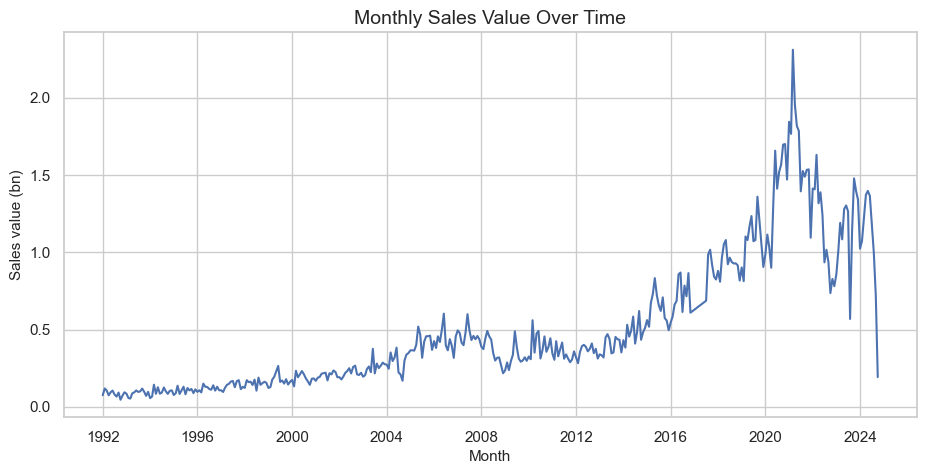

Insight: The highest monthly sales value was 2.31 bn in Mar 2021.


In [6]:
# 5. Monthly sales trend

monthly_sales = (
    df.groupby('month', as_index=False)['purchase_price']
      .sum()
      .assign(sales_bn=lambda x: x['purchase_price'] / 1_000_000_000)
)

ax = sns.lineplot(data=monthly_sales, x='month', y='sales_bn')
ax.set_title('Monthly Sales Value Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Sales value (bn)')
plt.show()

best_month = monthly_sales.loc[monthly_sales['sales_bn'].idxmax()]
print(f"Insight: The highest monthly sales value was {best_month['sales_bn']:.2f} bn in {best_month['month'].strftime('%b %Y')}.")

## 3) Business question: Which regions drive the most revenue?

This shows where the business is earning most of its sales value.

,region,sales_bn,sales_share,transactions
3,Zealand,94.965864,0.493075,39740
2,Jutland,81.478087,0.423045,49937
1,Fyn & islands,14.917703,0.077455,9264
0,Bornholm,1.237566,0.006426,1059


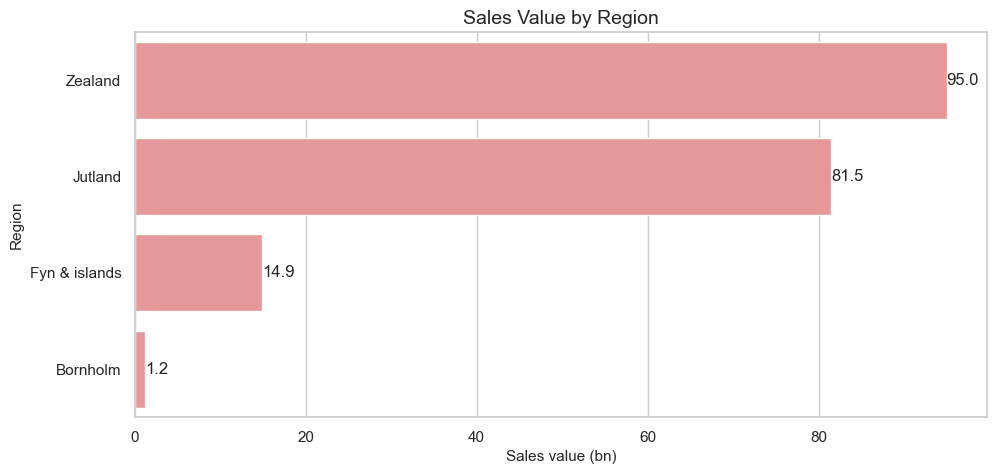

Insight: Zealand contributes 49.3% of total sales value.


In [7]:
# 6. Sales value by region

region_sales = (
    df.groupby('region', as_index=False)
      .agg(total_sales=('purchase_price', 'sum'), transactions=('house_id', 'count'))
)
region_sales['sales_bn'] = region_sales['total_sales'] / 1_000_000_000
region_sales['sales_share'] = region_sales['total_sales'] / region_sales['total_sales'].sum()
region_sales = region_sales.sort_values('sales_bn', ascending=False)

display(region_sales[['region', 'sales_bn', 'sales_share', 'transactions']])

ax = sns.barplot(data=region_sales, y='region', x='sales_bn', color=BAR_COLOR)
ax.set_title('Sales Value by Region')
ax.set_xlabel('Sales value (bn)')
ax.set_ylabel('Region')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.show()

top_region = region_sales.iloc[0]
print(f"Insight: {top_region['region']} contributes {top_region['sales_share']:.1%} of total sales value.")

## 4) Business question: Which regions are premium markets?

Revenue alone does not show pricing strength. Price per square meter shows where homes are more expensive per unit of space.

,region,avg_sqm_price_k
3,Zealand,20.854761
1,Fyn & islands,13.618188
2,Jutland,13.507225
0,Bornholm,10.601901


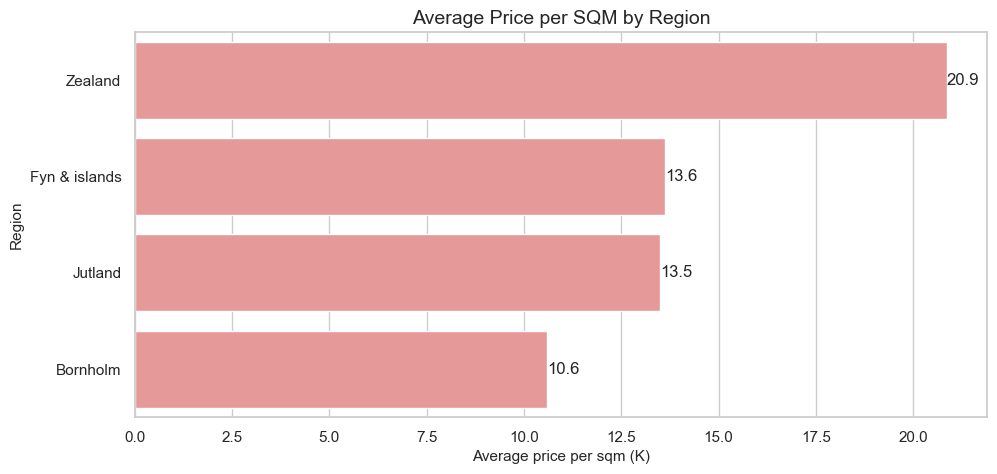

Insight: Zealand is the premium region with the highest average sqm price: 20.9K.


In [8]:
# 7. Average price per square meter by region

region_sqm = (
    df.groupby('region', as_index=False)['sqm_price']
      .mean()
      .assign(avg_sqm_price_k=lambda x: x['sqm_price'] / 1_000)
      .sort_values('avg_sqm_price_k', ascending=False)
)

display(region_sqm[['region', 'avg_sqm_price_k']])

ax = sns.barplot(data=region_sqm, y='region', x='avg_sqm_price_k', color=BAR_COLOR)
ax.set_title('Average Price per SQM by Region')
ax.set_xlabel('Average price per sqm (K)')
ax.set_ylabel('Region')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.show()

premium_region = region_sqm.iloc[0]
print(f"Insight: {premium_region['region']} is the premium region with the highest average sqm price: {premium_region['avg_sqm_price_k']:.1f}K.")

## 5) Business question: Which sales types are growing or declining?

For each sales type, we use the latest year where that sales type has data and compare it with the previous year.

,sales_type,year,yoy_growth_pct
31,auction,2023,29.095701
130,regular_sale,2024,-20.627577
97,other_sale,2024,-21.064443
64,family_sale,2024,-74.777118


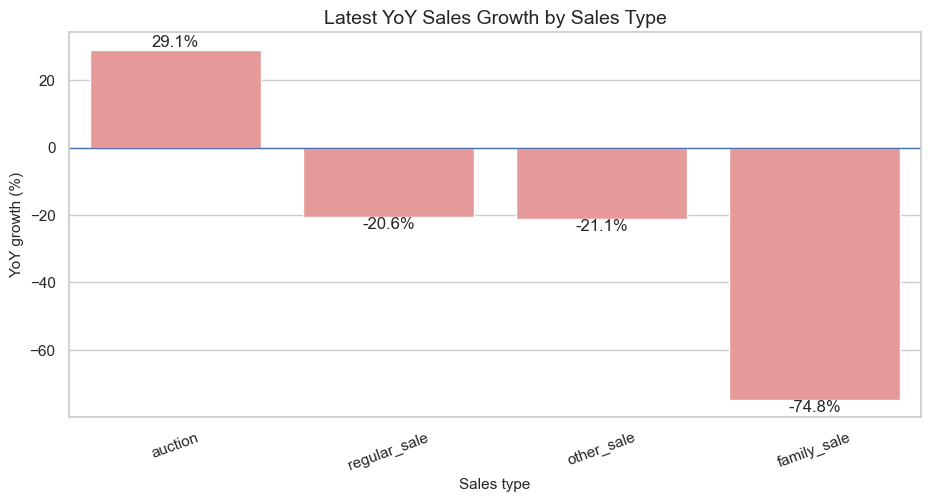

Insight: auction has the strongest latest YoY growth at 29.1%.
Watch-out: family_sale has the weakest latest YoY growth at -74.8%.


In [9]:
# 8. YoY sales growth by sales type

sales_type_year = (
    df.groupby(['sales_type', 'year'], as_index=False)['purchase_price']
      .sum()
      .sort_values(['sales_type', 'year'])
)

sales_type_year['yoy_growth_pct'] = sales_type_year.groupby('sales_type')['purchase_price'].pct_change() * 100

latest_yoy = (
    sales_type_year.dropna(subset=['yoy_growth_pct'])
                   .groupby('sales_type', as_index=False)
                   .tail(1)
                   .sort_values('yoy_growth_pct', ascending=False)
)

display(latest_yoy[['sales_type', 'year', 'yoy_growth_pct']])

ax = sns.barplot(data=latest_yoy, x='sales_type', y='yoy_growth_pct', color=BAR_COLOR)
ax.axhline(0, linewidth=1)
ax.set_title('Latest YoY Sales Growth by Sales Type')
ax.set_xlabel('Sales type')
ax.set_ylabel('YoY growth (%)')
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.show()

best_sales_type = latest_yoy.iloc[0]
weakest_sales_type = latest_yoy.iloc[-1]
print(f"Insight: {best_sales_type['sales_type']} has the strongest latest YoY growth at {best_sales_type['yoy_growth_pct']:.1f}%.")
print(f"Watch-out: {weakest_sales_type['sales_type']} has the weakest latest YoY growth at {weakest_sales_type['yoy_growth_pct']:.1f}%.")

## 6) Business question: Are offer prices close to purchase prices?

If points sit close to the diagonal line, offer and purchase prices are aligned. Points far from the line show larger differences.

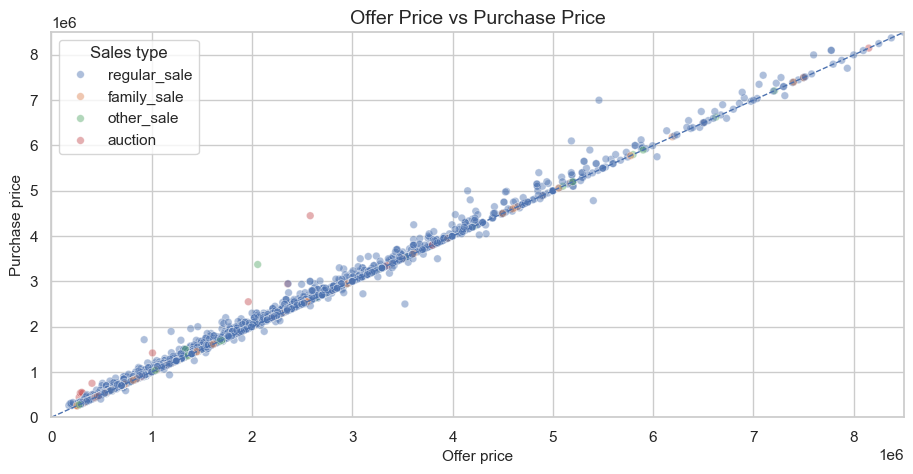

Insight: The average purchase-offer gap is 37,850. Positive means purchase price is higher than calculated offer price.


In [10]:
# 9. Offer price vs purchase price

# Sample for a cleaner scatter plot
scatter_df = df.sample(n=min(3000, len(df)), random_state=42)
limit = np.percentile(df[['offer_price', 'purchase_price']].to_numpy().ravel(), 99)

ax = sns.scatterplot(
    data=scatter_df,
    x='offer_price',
    y='purchase_price',
    hue='sales_type',
    alpha=0.45,
    s=30
)

# Diagonal reference line: offer price equals purchase price
plt.plot([0, limit], [0, limit], linestyle='--', linewidth=1)
plt.xlim(0, limit)
plt.ylim(0, limit)
ax.set_title('Offer Price vs Purchase Price')
ax.set_xlabel('Offer price')
ax.set_ylabel('Purchase price')
plt.legend(title='Sales type')
plt.show()

avg_gap = (df['purchase_price'] - df['offer_price']).mean()
print(f"Insight: The average purchase-offer gap is {avg_gap:,.0f}. Positive means purchase price is higher than calculated offer price.")

## 7) Business question: Which house types are most valuable?

This compares average purchase price with calculated offer price by house type.

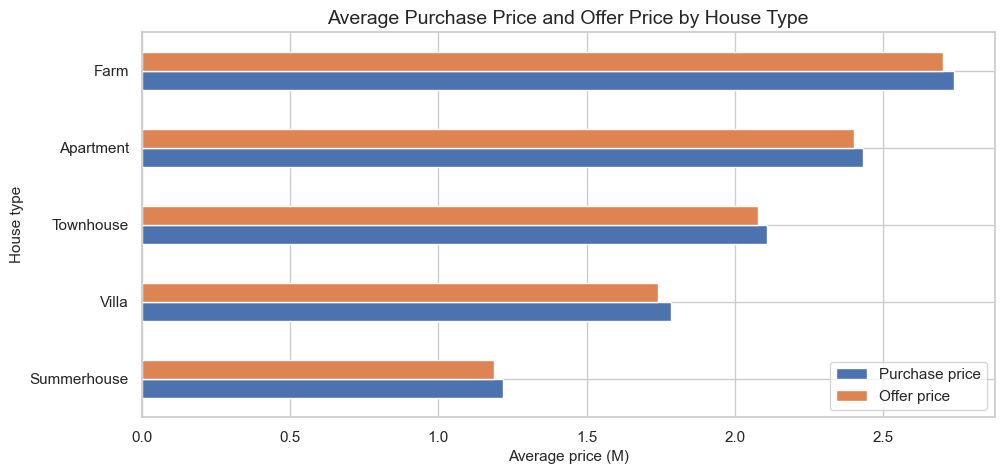

Insight: Farm has the highest average purchase price.


In [11]:
# 10. Average purchase price and offer price by house type

house_price = (
    df.groupby('house_type')[['purchase_price', 'offer_price']]
      .mean()
      .div(1_000_000)
      .sort_values('purchase_price', ascending=True)
)

ax = house_price.plot(kind='barh')
ax.set_title('Average Purchase Price and Offer Price by House Type')
ax.set_xlabel('Average price (M)')
ax.set_ylabel('House type')
plt.legend(['Purchase price', 'Offer price'])
plt.show()

most_expensive_house_type = house_price['purchase_price'].idxmax()
print(f"Insight: {most_expensive_house_type} has the highest average purchase price.")

## 8) Business question: Which sales type has the strongest offer price per square meter?

This is useful because a sales type may have lower total prices but stronger price per unit of space.

,sales_type,offer_to_sqm_k
3,regular_sale,16.442900
2,other_sale,16.021969
0,auction,14.020804
1,family_sale,12.764457


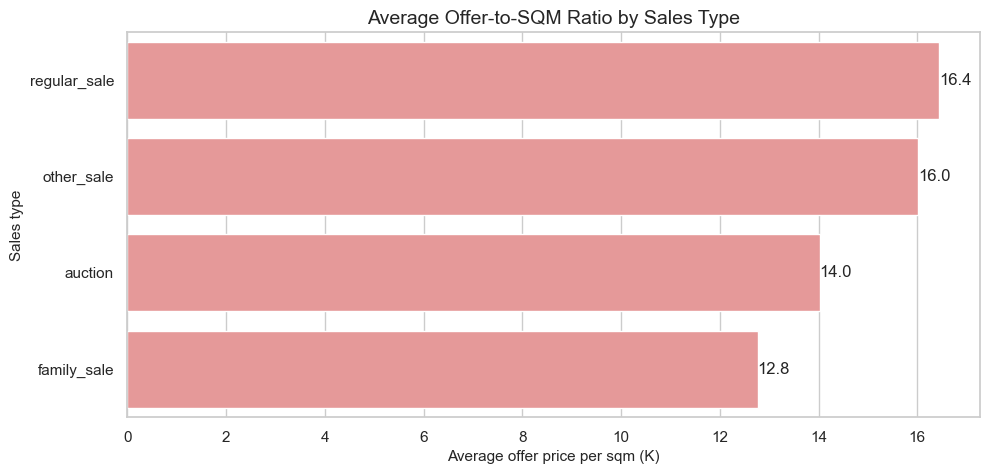

Insight: regular_sale has the strongest average offer-to-sqm ratio at 16.4K.


In [12]:
# 11. Offer to SQM ratio by sales type

offer_sqm = (
    df.groupby('sales_type', as_index=False)['offer_to_sqm_ratio']
      .mean()
      .assign(offer_to_sqm_k=lambda x: x['offer_to_sqm_ratio'] / 1_000)
      .sort_values('offer_to_sqm_k', ascending=False)
)

display(offer_sqm[['sales_type', 'offer_to_sqm_k']])

ax = sns.barplot(data=offer_sqm, y='sales_type', x='offer_to_sqm_k', color=BAR_COLOR)
ax.set_title('Average Offer-to-SQM Ratio by Sales Type')
ax.set_xlabel('Average offer price per sqm (K)')
ax.set_ylabel('Sales type')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.show()

strongest_type = offer_sqm.iloc[0]
print(f"Insight: {strongest_type['sales_type']} has the strongest average offer-to-sqm ratio at {strongest_type['offer_to_sqm_k']:.1f}K.")

## 9) Business question: Which cities should the business focus on?

Top cities by total sales value are strong candidates for sales, marketing, and investment focus.

,city,sales_bn,transactions,median_price_m
314,København S,4.106622,1275,2.847817
8,Aarhus C,3.336735,1059,2.650000
310,København A,2.747172,721,3.250000
418,Roskilde,2.620618,988,2.275000
445,Silkeborg,2.560912,1103,1.875000
3,Aalborg,2.520928,1136,1.750000
143,Frederiksberg,2.324401,674,2.982500
311,København K,2.148710,473,3.865000
245,Horsens,2.083653,1167,1.466000
302,Kolding,2.014751,1032,1.598000


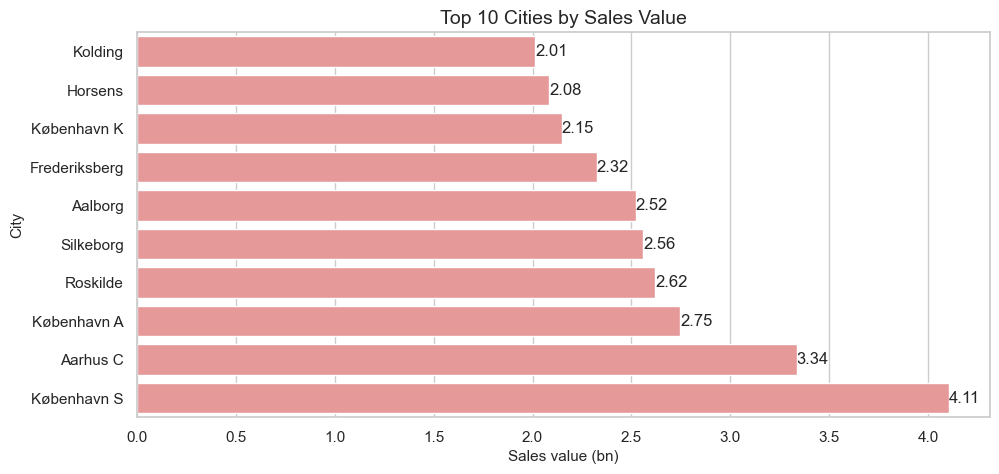

Insight: København S is the top city by sales value with 4.11 bn in sales.


In [13]:
# 12. Top cities by sales value

top_cities = (
    df.groupby('city', as_index=False)
      .agg(total_sales=('purchase_price', 'sum'), transactions=('house_id', 'count'), median_price=('purchase_price', 'median'))
      .assign(sales_bn=lambda x: x['total_sales'] / 1_000_000_000,
              median_price_m=lambda x: x['median_price'] / 1_000_000)
      .sort_values('sales_bn', ascending=False)
      .head(10)
)

display(top_cities[['city', 'sales_bn', 'transactions', 'median_price_m']])

ax = sns.barplot(data=top_cities.sort_values('sales_bn'), y='city', x='sales_bn', color=BAR_COLOR)
ax.set_title('Top 10 Cities by Sales Value')
ax.set_xlabel('Sales value (bn)')
ax.set_ylabel('City')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

focus_city = top_cities.iloc[0]
print(f"Insight: {focus_city['city']} is the top city by sales value with {focus_city['sales_bn']:.2f} bn in sales.")

## 10) Business question: How does property age affect pricing?

This checks whether newer or older homes command higher median prices.  
Only rows with non-negative property age are used. Future/pre-build rows are excluded from this chart.

,age_group,median_price_m,transactions
0,0-15 yrs,2.163775,10124
1,16-45 yrs,1.212500,28102
2,46-75 yrs,1.395000,26894
3,76-120 yrs,1.550000,20545
4,121-200 yrs,1.450000,6734
5,200+ yrs,1.431250,1096


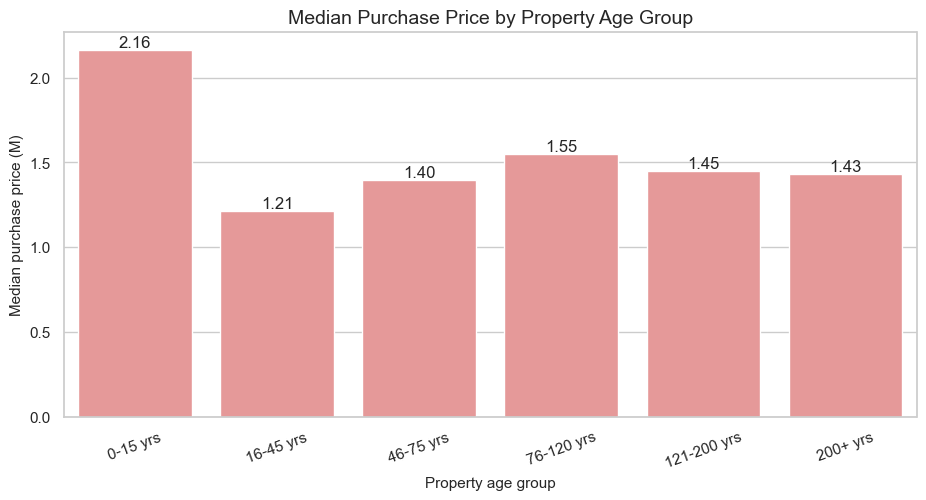

Insight: Homes aged 0-15 yrs have the highest median purchase price at 2.16M.


In [14]:
# 13. Property age vs median purchase price

age_df = df[df['valid_age']].copy()

age_df['age_group'] = pd.cut(
    age_df['property_age'],
    bins=[0, 15, 45, 75, 120, 200, 2000],
    labels=['0-15 yrs', '16-45 yrs', '46-75 yrs', '76-120 yrs', '121-200 yrs', '200+ yrs'],
    include_lowest=True
)

age_summary = (
    age_df.groupby('age_group', as_index=False)
          .agg(median_price=('purchase_price', 'median'), transactions=('house_id', 'count'))
)
age_summary['median_price_m'] = age_summary['median_price'] / 1_000_000

display(age_summary[['age_group', 'median_price_m', 'transactions']])

ax = sns.barplot(data=age_summary, x='age_group', y='median_price_m', color=BAR_COLOR)
ax.set_title('Median Purchase Price by Property Age Group')
ax.set_xlabel('Property age group')
ax.set_ylabel('Median purchase price (M)')
plt.xticks(rotation=20)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

highest_age_group = age_summary.loc[age_summary['median_price_m'].idxmax()]
print(f"Insight: Homes aged {highest_age_group['age_group']} have the highest median purchase price at {highest_age_group['median_price_m']:.2f}M.")

## Final business summary

This last cell turns the EDA into a short set of business takeaways.

In [15]:
# 14. Final business takeaways

print('Key business takeaways')
print('-' * 28)
print(f"1. Largest revenue region: {top_region['region']} ({top_region['sales_share']:.1%} of total sales value).")
print(f"2. Premium region by sqm price: {premium_region['region']} ({premium_region['avg_sqm_price_k']:.1f}K per sqm).")
print(f"3. Most expensive house type: {most_expensive_house_type}.")
print(f"4. Strongest sale type by offer-to-sqm ratio: {strongest_type['sales_type']} ({strongest_type['offer_to_sqm_k']:.1f}K per sqm).")
print(f"5. Top city by sales value: {focus_city['city']} ({focus_city['sales_bn']:.2f} bn).")
print(f"6. Highest median price age group: {highest_age_group['age_group']} ({highest_age_group['median_price_m']:.2f}M).")
print(f"7. Latest quarter units sold: {df[df['quarter'] == latest_quarter].shape[0]:,}.")
print(f"8. Last 12 months sales value: {df[df['date'] >= last_12_months_start]['purchase_price'].sum() / 1_000_000_000:.1f} bn.")

Key business takeaways
----------------------------
1. Largest revenue region: Zealand (49.3% of total sales value).
2. Premium region by sqm price: Zealand (20.9K per sqm).
3. Most expensive house type: Farm.
4. Strongest sale type by offer-to-sqm ratio: regular_sale (16.4K per sqm).
5. Top city by sales value: København S (4.11 bn).
6. Highest median price age group: 0-15 yrs (2.16M).
7. Latest quarter units sold: 77.
8. Last 12 months sales value: 13.7 bn.
